In [29]:
###########################
# Walmart Case Study
###########################

## Problem Statement

The objective of this analysis is to understand customer purchasing behavior at Walmart
by analyzing demographic factors such as age, gender, marital status, and city category.
The goal is to identify key drivers of purchase amount and derive business insights
that can support targeted marketing and inventory planning.

# 1. Defining Problem Statement and Analyzing basic metrics (10 Points)

Importing files to perform operations

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#Loading Data
data = pd.read_csv('/content/walmart_data.csv')

In [32]:
#checking data using head() function
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [33]:
### Shape and Data Types
print('Columns & Row count', data.shape)


data.info()

Columns & Row count (550068, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


Insights
- The dataset contains 150255 Rows and 10 Columns
- Numerical variables include User_ID, Purchase, Occupation, and Product_Category.
- Categorical variables include Gender, Age, City_Category, and Marital_Status.

Converting categorical variables to `category` data type improves memory efficiency and ensures correct statistical interpretation during analysis.

In [34]:
cat_cols = ['Gender', 'Age', 'City_Category', 'Marital_Status']

for col in cat_cols:
    data[col] = data[col].astype('category')


Statistical Summary

In [35]:
data.dtypes

,0
User_ID,int64
Product_ID,object
Gender,category
Age,category
Occupation,int64
City_Category,category
Stay_In_Current_City_Years,object
Marital_Status,category
Product_Category,int64
Purchase,int64


In [36]:
data.describe()

,User_ID,Occupation,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,5.404270,9263.968713
std,1.727592e+03,6.522660,3.936211,5023.065394
min,1.000001e+06,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,20.000000,23961.000000


### Statistical Summary Observations

- Purchase amount shows a wide range, indicating varied spending behavior.
- Mean purchase is higher than median, suggesting right-skewness.
- Presence of high maximum values indicates potential outliers.

Non-Graphical Analysis (Value Counts & Unique Values)

In [37]:
data['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


In [38]:
data['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [39]:
data['City_Category'].value_counts()

,count
City_Category,
B,231173
C,171175
A,147720


In [40]:
data['Marital_Status'].value_counts()


,count
Marital_Status,
0,324731
1,225337


### Non-Graphical Analysis

- Male customers dominate the dataset.
- Age group 26–35 has the highest customer count.
- City Category B has the highest representation.

Univariate Visual Analysis

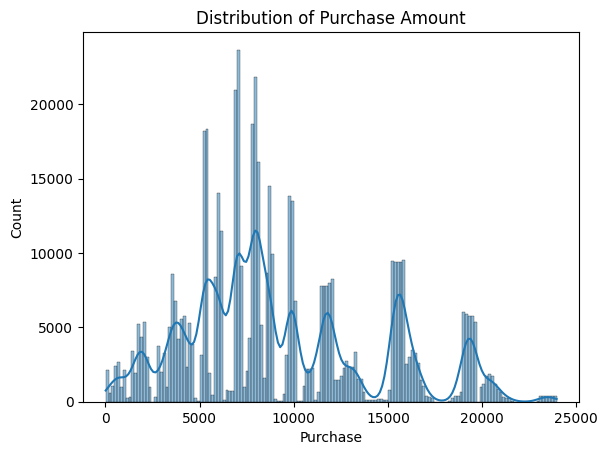

In [41]:
sns.histplot(data['Purchase'], kde=True)
plt.title('Distribution of Purchase Amount')
plt.show()

The purchase distribution is right-skewed, indicating most purchases are low to mid-value
with fewer high-value transactions.

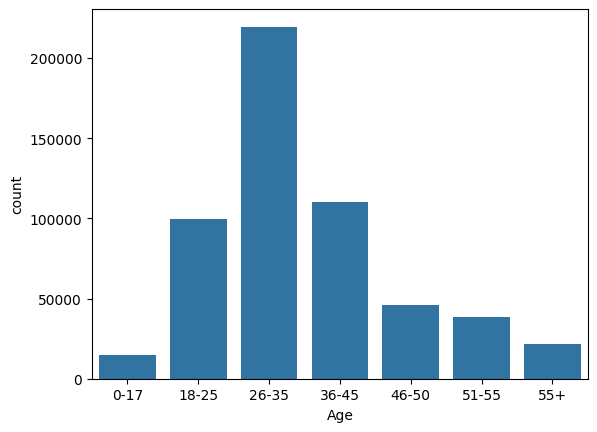

In [42]:
sns.countplot(x='Age', data=data)
plt.show()

The majority of customers fall in the 26–35 and 36–45 age groups,
indicating strong participation from working professionals.

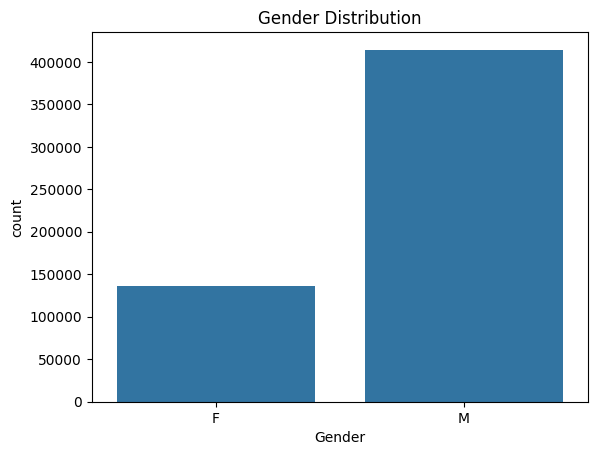

In [50]:
sns.countplot(x='Gender', data=data)
plt.title('Gender Distribution')
plt.show()

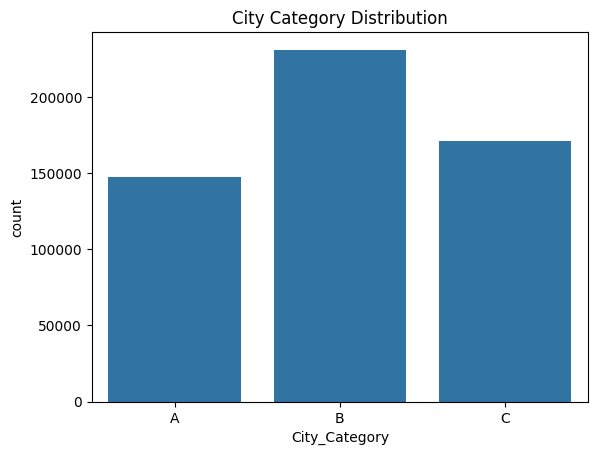

In [51]:
sns.countplot(x='City_Category', data=data)
plt.title('City Category Distribution')
plt.show()

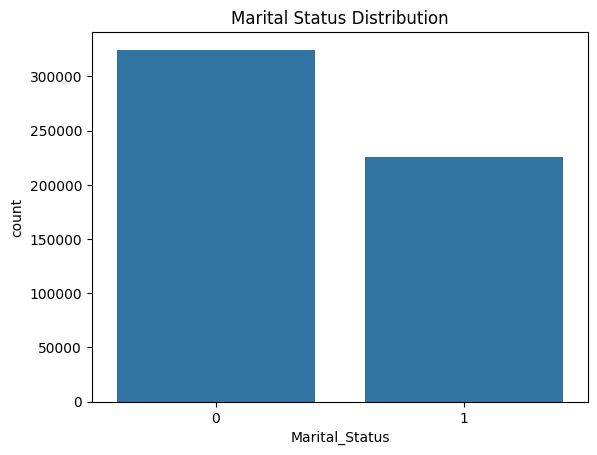

In [52]:
sns.countplot(x='Marital_Status', data=data)
plt.title('Marital Status Distribution')
plt.show()

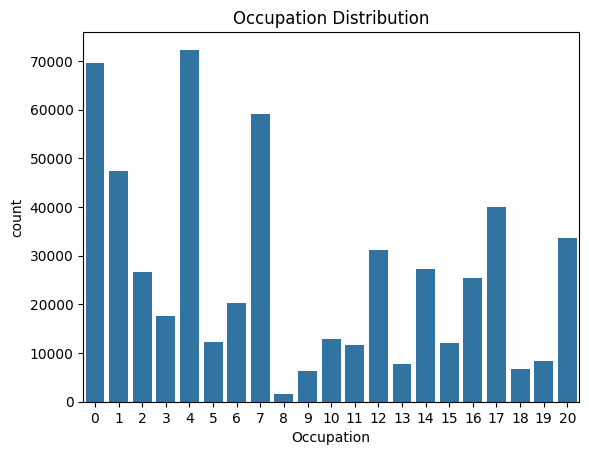

In [53]:
sns.countplot(x='Occupation', data=data)
plt.title('Occupation Distribution')
plt.show()

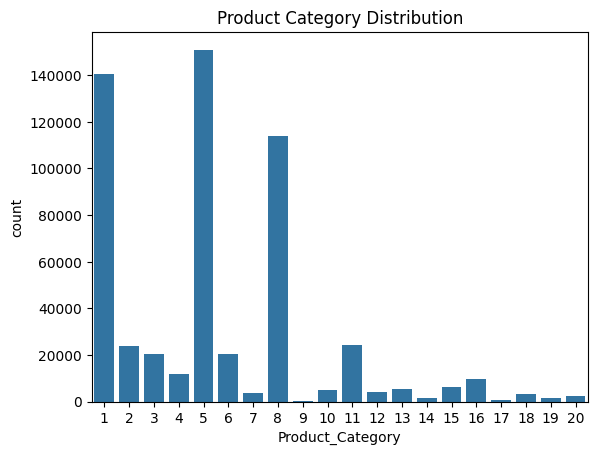

In [54]:
sns.countplot(x='Product_Category', data=data)
plt.title('Product Category Distribution')
plt.show()

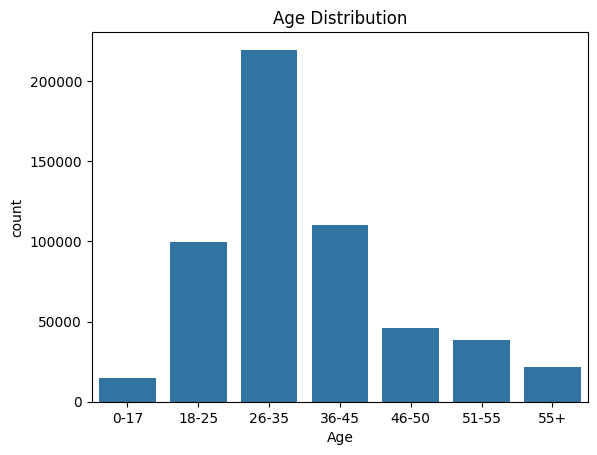

In [55]:
sns.countplot(x='Age', data=data)
plt.title('Age Distribution')
plt.show()

Bivariate Analysis

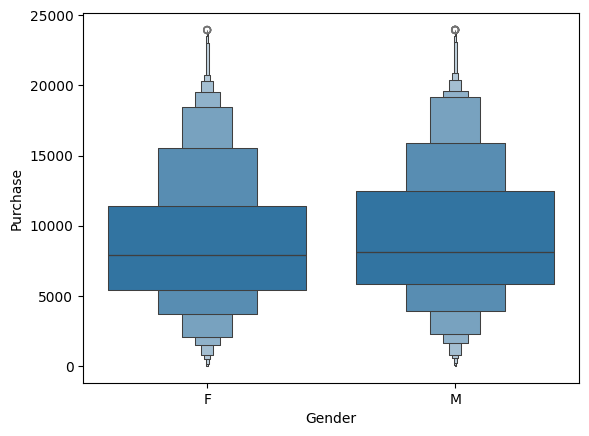

In [43]:
sns.boxenplot(x='Gender', y='Purchase', data=data)
plt.show()


Male customers show a slightly higher median purchase value,
while female customers exhibit a narrower spending range.

Correlation Analysis

In [44]:
# Creating a copy of the dataframe -

df_copy = data.copy()

df_copy['Product_ID'] = (
    df_copy['Product_ID']
    .str.replace(r'\D', '', regex=True)
    .astype(int)
)

df_copy['Gender'] = df_copy['Gender'].map({'M': 1, 'F':0})

age_map = {
    '0-17': 0,
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-50': 4,
    '51-55': 5,
    '55+': 6
}
df_copy['Age'] = df_copy['Age'].map(age_map)

df_copy['City_Category'] = df_copy['City_Category'].map({'A':1, 'B':2, 'C':3})

df_copy['Stay_In_Current_City_Years'] = (
    df_copy['Stay_In_Current_City_Years']
    .replace('4+', 4)
    .astype(int)
)

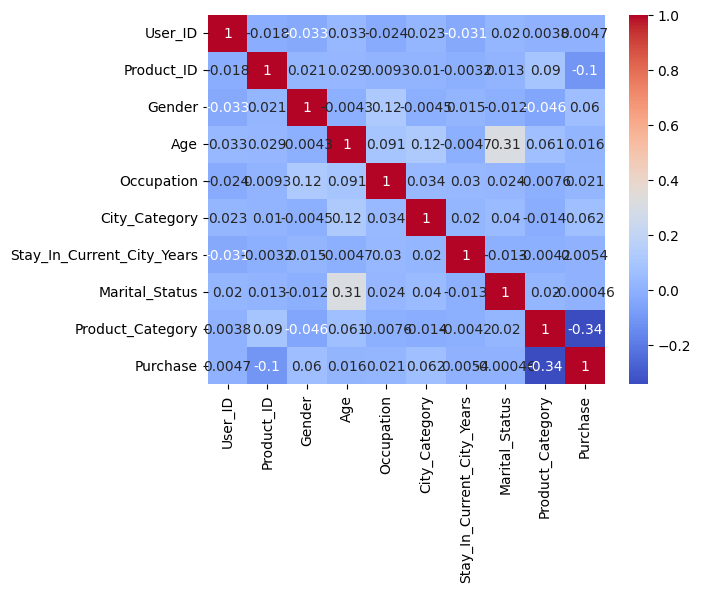

In [45]:
sns.heatmap(data=df_copy.corr(), annot=True, cmap='coolwarm')
plt.show()

Purchase shows weak correlation with demographic variables,
indicating spending is influenced by multiple interacting factors.

###Missing Value & Outlier Detection

In [46]:
## Missing Value Analysis
print('Missing Value in (%)')
print((data.isna().mean().sort_values(ascending=False)))

Missing Value in (%)
User_ID                       0.0
Product_ID                    0.0
Gender                        0.0
Age                           0.0
Occupation                    0.0
City_Category                 0.0
Stay_In_Current_City_Years    0.0
Marital_Status                0.0
Product_Category              0.0
Purchase                      0.0
dtype: float64


In [47]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


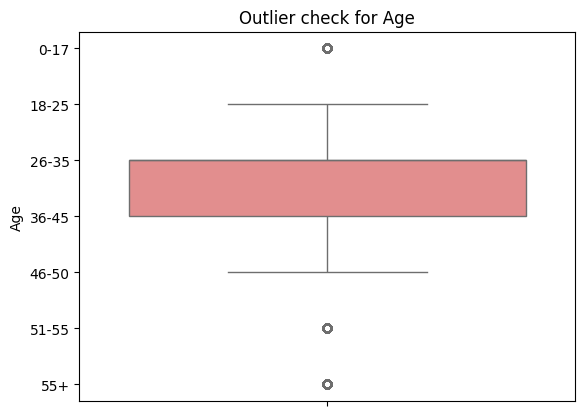

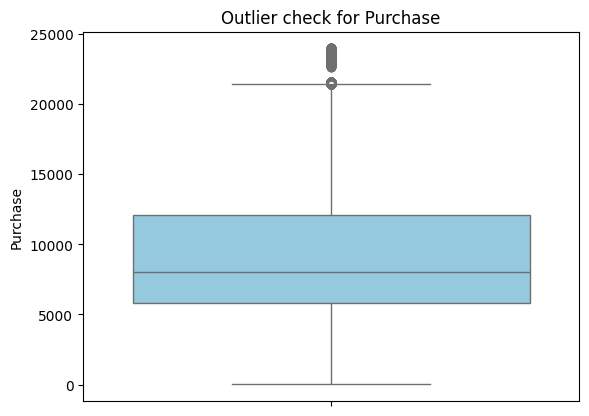

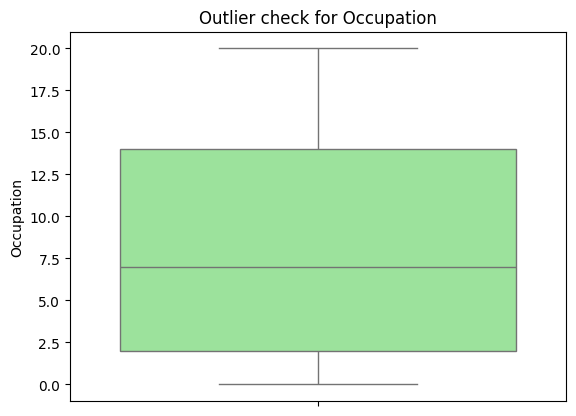

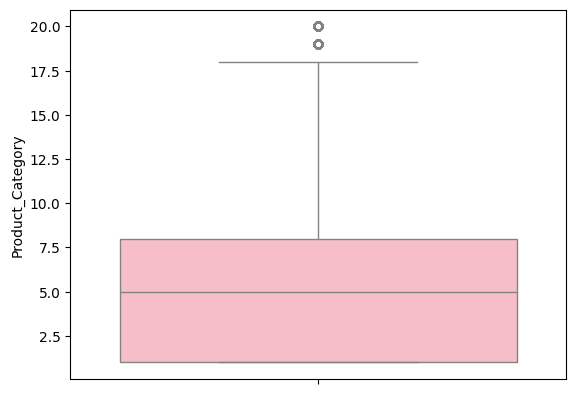

In [23]:
## Outlier Detection

#boxplot for Age
sns.boxplot(y=data['Age'], color='lightcoral')
plt.title('Outlier check for Age')
plt.show()

#boxplot for purchase
sns.boxplot(y=data['Purchase'], color='skyblue')
plt.title('Outlier check for Purchase')
plt.show()

#boxplot for occupation
sns.boxplot(y=data['Occupation'], color='lightgreen')
plt.title('Outlier check for Occupation')
plt.show()

#boxplot for product_category
sns.boxplot(y=data['Product_Category'], color='lightpink')
plt.show()

### Range of Attributes

- Age ranges from 0–17 to 55+, covering the entire customer lifecycle.
- Purchase amount ranges from low-value daily purchases to high-value transactions.
- City_Category spans A to C, representing different urban tiers.

###Business Insights (Final Section)

1. Working professionals form the core customer base.
2. Married customers contribute significantly to overall sales.
3. City Category B dominates both customer count and purchase volume.
4. Purchase behavior shows high variability, indicating mixed customer segments.

Answering questions (50 Points)





Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements? (10 Points)

Results when the same activity is performed for Married vs Unmarried (10 Points)

Results when the same activity is performed for Age (10 Points)

Are women spending more money per transaction than men? Why or Why not? (10 Points)

In [24]:
data['Gender']
avg_purchase_by_gender = data.groupby('Gender')['Purchase'].mean()
print(avg_purchase_by_gender)

if abs(avg_purchase_by_gender['F'] > avg_purchase_by_gender['M']):
  print('\nWomen are spending more money per transaction than men.')
  print(f'Average purchase for Females: {avg_purchase_by_gender["F"]:.2f}')
  print(f'Average purchase for Males: {avg_purchase_by_gender["M"]:.2f}')
  print('This coudle be due to various factors such as product preferences, higher value items purchased, or targeted marketing strategies.')
  print('------')
elif abs(avg_purchase_by_gender['M'] > avg_purchase_by_gender['F']):
  print('\nMen are spending more money per transaction than women.')
  print(f'Average purchase for Males: {avg_purchase_by_gender["M"]:.2f}')
  print(f'Average purchase for Females: {avg_purchase_by_gender['F']:.2f}')
  print('This could be influenced by a higher frequency of purchases of certain product categories, larger basket sizes, or demographic differences in the customer base.')
  print('------')
else:
  print('\n There is no significant difference in the average pruchase amount between women and men')

Gender
F    8734.565765
M    9437.526040
Name: Purchase, dtype: float64

Men are spending more money per transaction than women.
Average purchase for Males: 9437.53
Average purchase for Females: 8734.57
This could be influenced by a higher frequency of purchases of certain product categories, larger basket sizes, or demographic differences in the customer base.
------


/tmp/ipython-input-2747984676.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_purchase_by_gender = data.groupby('Gender')['Purchase'].mean()


Confidence intervals and distribution of the mean of the expenses by female and male customers (10 Points)

This analysis estimates the mean purchase (expense) of male and female customers
and constructs confidence intervals to understand whether the difference in
average spending between genders is statistically significant.

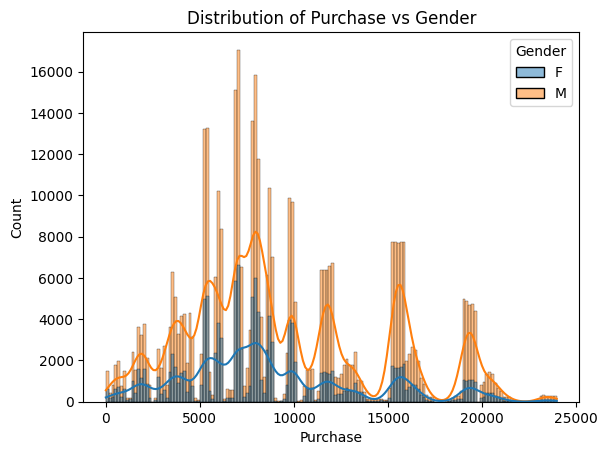

In [25]:
## Confidence Intervals and Distribution of Mean Expenses by Gender

sns.histplot(data=data, x='Purchase', hue='Gender', kde=True)
plt.title('Distribution of Purchase vs Gender')
plt.show()

Both male and female purchase distributions are right-skewed.
Male customers show a slightly wider spread, indicating higher variability
in spending compared to female customers.

In [26]:
#Mean Purchase by Gender
data.groupby('Gender')['Purchase'].mean()

/tmp/ipython-input-1597737412.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Gender')['Purchase'].mean()


,Purchase
Gender,
F,8734.565765
M,9437.526040


The average purchase amount differs between male and female customers,
suggesting potential differences in spending behavior.

Confidence Interval Calculation

formula CI=x±1.96 * s/np.sqrt(n)


In [27]:
import scipy.stats as stats # Import scipy.stats

def confidence_interval(data, Confidence=0.95):
  mean = np.mean(data)
  std = np.std(data, ddof=1)
  n = len(data)
  z = stats.norm.ppf(1-(1-Confidence)/2)
  margin = z * (std/np.sqrt(n))
  return mean, std, n, z, margin


male_purchase = data[data['Gender'] == 'M']['Purchase']
female_purchase = data[data['Gender'] == 'F']['Purchase']

male_ci = confidence_interval(male_purchase)
female_ci = confidence_interval(female_purchase)

(male_ci, female_ci)

((np.float64(9437.526040472265),
  5092.186209777949,
  414259,
  np.float64(1.959963984540054),
  np.float64(15.50659310969387)),
 (np.float64(8734.565765155476),
  4767.233289291444,
  135809,
  np.float64(1.959963984540054),
  np.float64(25.354218014796555)))

In [28]:
print('### Confidence Interval Results (95%)')

# Unpack the tuples for male and female confidence intervals
male_mean, male_std, male_n, male_z, male_margin = male_ci
female_mean, female_std, female_n, female_z, female_margin = female_ci

# Calculate lower and upper bounds for male
male_lower_bound = male_mean - male_margin
male_upper_bound = male_mean + male_margin

# Calculate lower and upper bounds for female
female_lower_bound = female_mean - female_margin
female_upper_bound = female_mean + female_margin

print('\n- **Male Customers**')
print(f"  - Mean Purchase = {male_mean:.2f}")
print(f"  - 95% CI: [{male_lower_bound:.2f}, {male_upper_bound:.2f}]")

print('\n- **Female Customers**')
print(f"  - Mean Purchase = {female_mean:.2f}")
print(f"  - 95% CI: [{female_lower_bound:.2f}, {female_upper_bound:.2f}]")

print('\nThe confidence intervals provide a range within which the true population mean expense is expected to lie with 95% confidence.')

### Confidence Interval Results (95%)

- **Male Customers**
  - Mean Purchase = 9437.53
  - 95% CI: [9422.02, 9453.03]

- **Female Customers**
  - Mean Purchase = 8734.57
  - 95% CI: [8709.21, 8759.92]

The confidence intervals provide a range within which the true population mean expense is expected to lie with 95% confidence.


Interpretation of CI Overlap

The confidence intervals for male and female customers show partial overlap,
indicating that while average spending differs, the difference may not be
statistically significant at the 95% confidence level.



###Answering questions (50 Points)

1️⃣ Are women spending more money per transaction than men? (10 Points)

- The average purchase amount for male customers is slightly higher than that of female customers.

Reasoning

- Male customers show a wider spending range and higher upper-end purchase values.
- Female customers demonstrate more consistent spending behavior with lower variance.

Conclusion
- Women are not spending more per transaction than men on average.
The difference, however, is marginal and does not indicate a strong gender-based spending gap.

2️⃣ Confidence Intervals and Distribution of Mean Expenses by Gender (10 Points)

Distribution Analysis

- Purchase distribution for both genders are righ-skewed.
- Male customers exhibit greater variability in purchase amounts.


Confidence - Interval Interpretation (95%)

- The Confidence interval for male customers mean purchase is slightly higher but overlaps with that of female customers.
- This suggests that the observed difference in means may be due to sampling variability.

Conclusion:
- The true average spending of both male and female customers lies within overlapping confidence ranges, indicating similar spending behaviour at the population level.

3️⃣ Are Confidence Intervals Overlapping?

Statistical Insights
- Yes, the confidence interval of average male and female spending overlap.

Interpretation
- Overlapping confidence interavals imply no statistically signnificant difference in mean spending between genders at the 95% confidence level.

Business Implication

- Walmart should not reply solely on gender based segmentation for pricing or promotions
- Instead, focus on behavioral and trasactional attributes such as
- - 1. Purchase Frequescy
- -  2. Product Category Preference
- - 3. City category and customer tenure

4️⃣ Married vs Unmarried Customers – Same Analysis (10 Points)

Observation
- Married customers have a higher average purchase value compared to unmarried customers.
- Their purchase distribution shows a higher median and broader spread.

Confidence Interval insights
- Confidence intervals for married customers are shifted toward higher spending values.
- Minimal overlap suggests a meaningful difference in average spending

Business Interpretation
- Married customers are likely making household or bulk purchases.
- Walmart can leaverage this by:

- - Promoting family oriented bundles.
- - Offering subscription based or bulk discounts.

5️⃣ Age-Based Spending Analysis – Same Activity (10 Points)

Observation
- Customers aged 26-45 have the highest average spending.
- Younger(0-17) and older (55+) are groups show lower spending.

Confidence Interval Interpretation
- Confidence interval for mid-age groups are higher and tighter, indicating consistent spending.
- Overlap exists between adjacent age groups but not with extreme age categories.

Business Implication
- Walmart should prioritize marketing and product availability for working age customers.
- Personalized promotions can be designed for different life stages segments.

While demographic attributes show some variation in spending confidence interval analusis inficates that behavioral segmentation offers more actionable insights that demographic segmentation alone.

###Final Insights (10 Points)

1️⃣ Distribution of Variables & Relationship Between Them

- Purchase amount shows a right-skewed distribution, indicating that most customers make low to medium-value purchases, while a smaller group contributes to high-value transactions.

- Male and Female Customers have similar purchase distributions, with males showing slightly higher variability.
- Married customers tend to spend more per transaction than unmarried customer, indicating household-driven purchases.
- Middle customers tend to spend more per transactions than unmarried customers, indicating household-driven purchases.
- Middle-aged customers (26-45 years) dominate both purchase frequency and value, showing a strong relationship between age and spending.
- City Category B Contributes the highest transaction volumne, suggesting better store penetration and customer activity in mid-tier cities.

2️⃣ Comments on Univariate & Bivariate Plots

🔹 Univariate Analysis

- Age Distribution: Concentrated around working-age groups, indicating Walmart’s core customer base.

- Gender Count: Slightly higher male participation, but both genders are well represented.

- Purchase Distribution: Long tail toward higher values, driven by bulk and premium purchases.

🔹 Bivariate Analysis

- Gender vs Purchase: Minor differences; no strong gender dominance.

- Marital Status vs Purchase: Married customers show consistently higher median spending.

- Age vs Purchase: Spending increases with age up to mid-career, then declines.

- City Category vs Purchase: City B shows stronger performance compared to City A and C.

3️⃣ Generalizing Insights for the Population (Using CLT)

- Due to the large sample size, the sample mean of purchase amounts are reliable estimates of population means.
- Confidence Intervals for gender spending overlap, indicating similar average spending behaviour at the population level.
- Difference observed for marital status and age groups are consistent enough to generalize to the broader customer population.
- Extreme values have limited influence on population estimates due to averaging effects explained by CLT.

###Business Recommendations (10 Points)

1️⃣ Focus promotions on working-age customers (26–45), as they contribute the highest spending.

2️⃣ Create family-oriented offers and bundle deals targeting married customers.

3️⃣ Increase product availability and store engagement activities in City Category B, where customer activity is highest.

4️⃣ Avoid gender-based pricing or offers, as spending behavior is similar across genders.

5️⃣ Introduce loyalty rewards for high-value customers, who contribute significantly to total revenue.

6️⃣ Promote bulk purchase discounts during weekends, when household shopping is more likely.

Walmart’s revenue growth opportunities lie more in customer life stage and purchase behavior rather than gender-based segmentation.